# Joint Perturb-seq Perturbation Analysis

Jin et al. 2020 (*Nature Neuroscience*) used Perturb-seq to map the transcriptional
effects of neuronal gene knockdowns in excitatory neurons.

This tutorial uses a subset of the data to demonstrate the full **causarray** workflow:
- **29 perturbations**, ~2 900 cells, ~3 200 genes
- Data downloaded from the [Broad Single Cell Portal](https://singlecell.broadinstitute.org/single_cell/study/SCP1184)

**Pipeline overview**
```
perturbseq-exneu.h5ad
      |
      v  prep_causarray_data
   Y, A, X
      |
      v  estimate_r  →  select r (JIC criterion)
      |
      v  fit_gcate   →  estimate latent confounders U
      |
      v  LFC         →  doubly-robust log-fold changes
```

In [1]:
import os 
import sys
sys.path.append('../../..')

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

import scanpy as sc

from causarray import (
    prep_causarray_data, fit_gcate, LFC, estimate_propensity_scores,
    summarize_propensity_scores, plot_propensity_scores, refit_propensity_scores,
    summarize_treatment_associations, plot_treatment_associations,
)

The data can be downloaded from the Broad Single Cell Portal
(https://singlecell.broadinstitute.org/single_cell/study/SCP1184).
Here we use a pre-processed subset saved as `perturbseq-exneu.h5ad`.

In [2]:
adata = sc.read_h5ad('perturbseq-exneu.h5ad')
adata

AnnData object with n_obs × n_vars = 2926 × 3221
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'nGene', 'nUMI', 'Cluster', 'Batch', 'CellType', 'Perturbation', 'isKey', 'isAnalysed', 'SCRUBLET'

For running causarray, we require the following inputs:

- `Y`: the cell-by-gene gene expression matrix.
- `A`: the cell-by-condition binary matrix of the perturbation/treatment conditions.
- `X, X_A`: (optional) the cell-by-covariate matrix of the covariates of interest for outcome and propensity models.

Here, `Y` and `A` can be dataframes.

In [3]:
Y = pd.DataFrame(adata.X.copy(), columns=adata.var.index)
A = pd.get_dummies(adata.obs['Perturbation'], columns=['Perturbation'], drop_first=False).drop(columns=['GFP'])

Y, A, X, X_A = prep_causarray_data(Y, A)
a = A.shape[1]
a

29

### Number of latent factors

We estimate the number of unmeasured confounders *r* using the JIC criterion.
JIC is a penalised-likelihood score computed by fitting GCATE for each candidate
value of *r*; the optimal *r* minimises JIC.

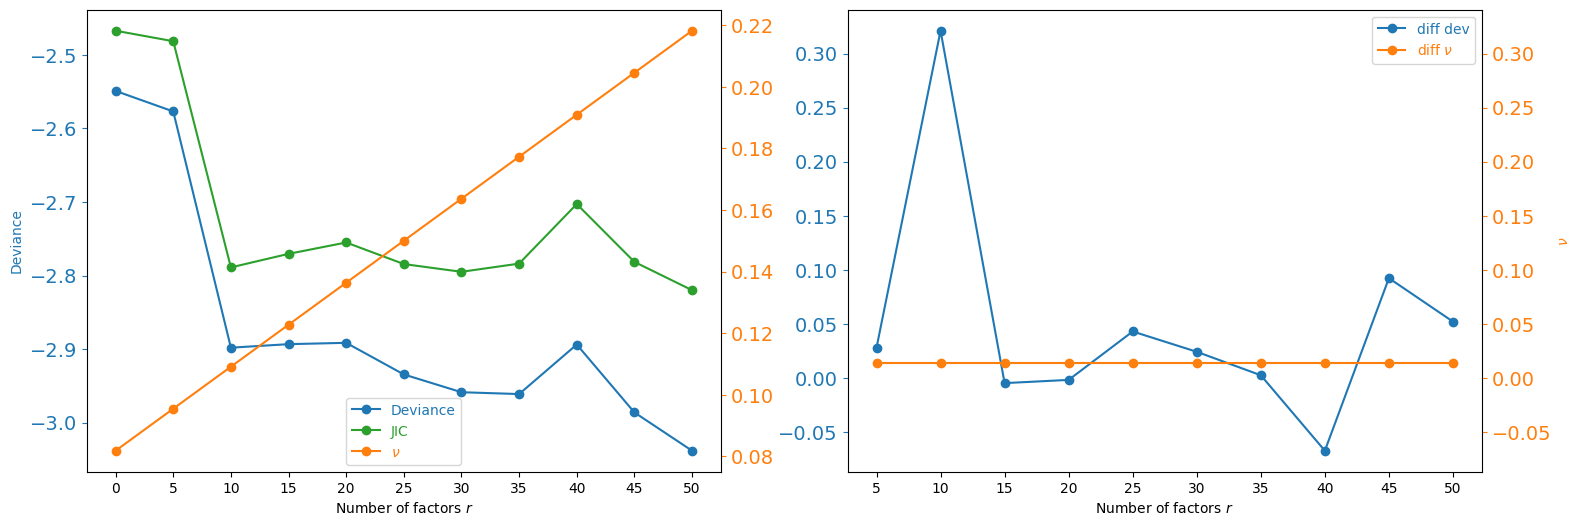

In [4]:
from causarray import estimate_r, plot_r
# df_r = estimate_r(Y, X, A, np.arange(5,55,5))
# df_r.to_csv('perturbseq-r.csv', index=False)
df_r = pd.read_csv('perturbseq-r.csv')
fig = plot_r(df_r)

### Estimate unmeasured confounders

We run **GCATE** with the selected *r* to estimate latent factors that capture
unmeasured confounders (e.g. cell-cycle phase, technical variation).
The estimated factors are appended to the covariate matrix before calling `LFC`.

In [5]:
r = 10
res_1, res_2 = fit_gcate(Y, X, A, r, verbose=True,
    kwargs_es_1=dict(rel_tol=2e-4, max_iters=30),
    kwargs_es_2=dict(rel_tol=2e-4, max_iters=30),
)
U = res_2['U']
print(f"\nStep 1  -- epochs: {res_1['n_iter']},  best NLL: {min(res_1['hist']):.6f}")
print(f"Step 2  -- epochs: {res_2['n_iter']},  best NLL: {min(res_2['hist']):.6f}")

{'d': 30, 'n': 2926, 'p': 3221, 'r': 10}
'Estimating initial latent variables with GLMs...'
'Fitting nb GLM (fast)...'


'Estimating initial coefficients with GLMs...'
'Fitting nb GLM (fast)...'


{'kwargs_es': {'max_iters': 30,
               'patience': 5,
               'rel_tol': 0.0002,
               'tolerance': 0.0,
               'warmup': 0},
 'kwargs_glm': {'disp_glm': array([ 1.11673516,  1.06870944,  1.16716468, ..., 12.58818245,
       16.46897663,  1.70852614], shape=(3221,)),
                'family': 'nb',
                'size_factor': array([0.53193358, 0.87362742, 1.2235467 , ..., 0.5593801 , 0.73025856,
       0.77857223], shape=(2926,))},
 'kwargs_ls': {'C': 1000.0,
               'alpha': 0.1,
               'beta': 0.5,
               'max_iters': 20,
               'recheck_interval': 10,
               'sparsity_boost': 2.0,
               'sparsity_threshold': 0.5,
               'tol': 0.0001,
               'tol_cell': 0.0001,
               'tol_gene': 0.0001,
               'warmup_iters': 0}}
'Fitting GCATE (step 1)...'


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:07<?, ?it/s, nll=1.71]

...

 97%|█████████▋| 29/30 [00:15<00:00,  2.63it/s, nll=1.72]

 97%|█████████▋| 29/30 [00:15<00:00,  2.63it/s, nll=1.72]

100%|██████████| 30/30 [00:15<00:00,  2.65it/s, nll=1.72]

100%|██████████| 30/30 [00:15<00:00,  1.94it/s, nll=1.72]


Step 1  -- epochs: 29,  best NLL: 1.705777
Step 2  -- epochs: 29,  best NLL: 1.722559


### Estimate log-fold change based on counterfactuals

Next, we apply causarray to estimate the causal effects of perturbations on gene expression. Here the 106 GFP control cells and the perturbation groups (median 89 cells) are approximately balanced. We therefore use pooled variance to retain power in this relatively small comparison. This is a dataset-specific choice: unequal variance remains preferable when arm sizes or effective sample sizes are meaningfully unbalanced, when pseudo-outcome variability differs between arms, and for the Replogle and case-control tutorials.

In [6]:
offsets = np.log(res_2['kwargs_glm']['size_factor']) # use the precomputed size factors
df_res, estimation = LFC(Y, np.c_[X, U], A, np.c_[X_A, U], offset=offsets, usevar='pooled', verbose=True)

'Estimating LFC...'
{'a': 29, 'd': 11, 'd_A': 12, 'estimands': 'LFC', 'n': 2926, 'p': 3221}
{'offset': array([-0.63123664, -0.13510128,  0.20175377, ..., -0.58092607,
       -0.31435661, -0.25029351], shape=(2926,)),
 'random_state': 0,
 'verbose': True}
'Fit propensity score models...'
{'C': 1.0,
 'class_weight': 'balanced',
 'fit_intercept': False,
 'random_state': 0,
 'verbose': False}
'Fit outcome models...'


'Fitting nb GLM (fast)...'


('Fast GLM coefficients exceed bound (max|B|=1.53e+05 > 1e+04); falling back '
 'to statsmodels...')
'Estimating dispersion parameter...'
'Fitting poisson GLM with offset...'


'Fitting nb GLM with offset...'


  0%|          | 0/3221 [00:00<?, ?it/s]

...

 21%|██        | 6/29 [00:00<00:00, 50.13it/s]

 45%|████▍     | 13/29 [00:00<00:00, 59.00it/s]

 69%|██████▉   | 20/29 [00:00<00:00, 62.10it/s]

 93%|█████████▎| 27/29 [00:00<00:00, 60.95it/s]

100%|██████████| 29/29 [00:00<00:00, 59.89it/s]

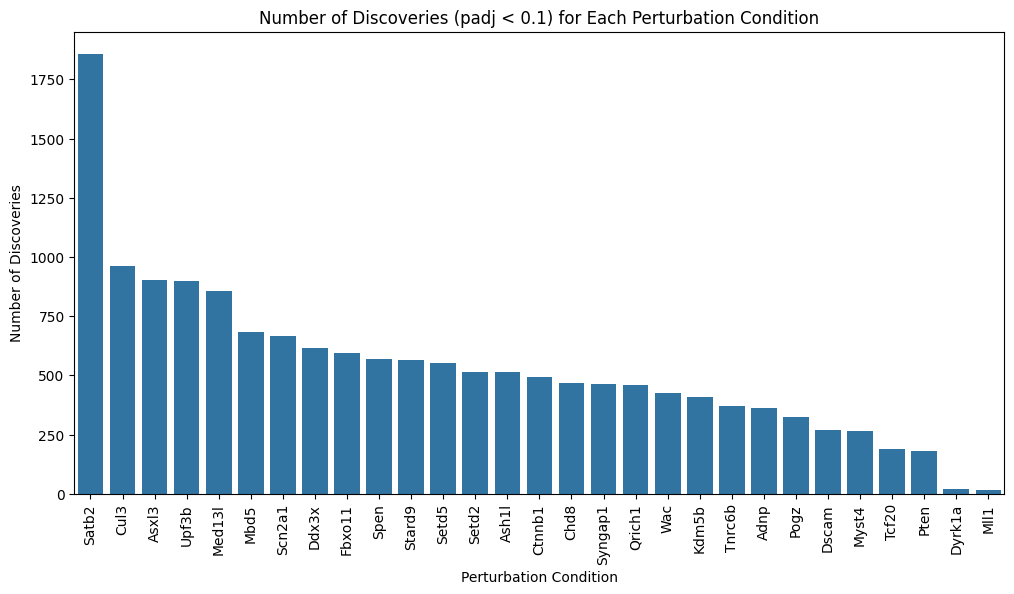

Total significant gene-perturbation pairs (padj < 0.1): 15,456
Perturbation  Count
       Satb2   1858
        Cul3    962
       Asxl3    901
       Upf3b    899
      Med13l    855
        Mbd5    682
      Scn2a1    664
       Ddx3x    616
      Fbxo11    593
        Spen    567
      Stard9    566
       Setd5    552
       Setd2    516
       Ash1l    512
      Ctnnb1    491
        Chd8    469
     Syngap1    462
      Qrich1    459
         Wac    424
       Kdm5b    410
      Tnrc6b    371
        Adnp    364
        Pogz    326
       Dscam    270
       Myst4    264
       Tcf20    187
        Pten    179
      Dyrk1a     20
        Mll1     17


,negative_fraction,median_tau,significant,significant_negative,significant_positive
trt,,,,,
Med13l,0.668115,-0.097780,855,653,202
Scn2a1,0.667495,-0.081455,664,543,121
Mbd5,0.665011,-0.078835,682,536,146
Upf3b,0.663148,-0.083435,899,715,184
Satb2,0.661596,-0.142076,1858,1398,460
Setd5,0.659112,-0.082058,552,458,94
Chd8,0.646383,-0.063514,469,374,95
Ctnnb1,0.645141,-0.062003,491,371,120
Asxl3,0.643589,-0.073545,901,696,205


In [7]:
# Filter the results for significant discoveries
significant_discoveries = df_res[df_res['padj'] < 0.1]

# Count the number of discoveries for each perturbation condition
discovery_counts = significant_discoveries['trt'].value_counts().reset_index()
discovery_counts.columns = ['Perturbation', 'Count']

# Plot the number of discoveries for each perturbation condition
plt.figure(figsize=(12, 6))
sns.barplot(data=discovery_counts, x='Perturbation', y='Count')
plt.xticks(rotation=90)
plt.title('Number of Discoveries (padj < 0.1) for Each Perturbation Condition')
plt.xlabel('Perturbation Condition')
plt.ylabel('Number of Discoveries')
plt.show()
print(f"Total significant gene-perturbation pairs (padj < 0.1): {len(significant_discoveries):,}")
print(discovery_counts.to_string(index=False))

direction = df_res.assign(
    significant=df_res['padj'] < 0.1,
    significant_negative=(df_res['padj'] < 0.1) & (df_res['tau'] < 0),
    significant_positive=(df_res['padj'] < 0.1) & (df_res['tau'] > 0),
).groupby('trt').agg(
    negative_fraction=('tau', lambda value: (value < 0).mean()),
    median_tau=('tau', 'median'),
    significant=('significant', 'sum'),
    significant_negative=('significant_negative', 'sum'),
    significant_positive=('significant_positive', 'sum'),
).sort_values('negative_fraction', ascending=False)
display(direction)

### Propensity-score and positivity diagnostics

Positivity requires treatment and control cells with comparable covariates. We use five-fold out-of-fold scores with `class_weight='balanced'`, matching the propensity model used by `LFC`, so that an overfit model cannot make its own training separation look stronger than it generalises. The table reports histogram overlap, the fraction outside `[0.05, 0.95]`, and inverse-weight effective sample size (ESS). Use `class_weight=None` here together with `ps_class_weight=None` in `LFC` for a calibrated-probability sensitivity analysis.

,treatment,n_control,n_treated,prevalence,overlap_ratio,auc,brier_score,outside_overlap_fraction,clipped_fraction,ess_control,ess_treated,ess_control_fraction,ess_treated_fraction,score_q01,score_median,score_q99
18,Satb2,106,51,0.324841,0.164077,0.940437,0.096756,0.140127,0.0,41.828404,36.409911,0.394608,0.713920,0.004029,0.314227,0.934044
11,Mbd5,106,119,0.528889,0.303393,0.891787,0.134982,0.048889,0.0,38.719901,52.918970,0.365282,0.444697,0.022886,0.510299,0.925013
12,Med13l,106,75,0.414365,0.313208,0.869182,0.148720,0.016575,0.0,74.125171,34.379413,0.699294,0.458392,0.033957,0.486809,0.899440
27,Upf3b,106,100,0.485437,0.317547,0.894434,0.135306,0.029126,0.0,67.812022,69.887297,0.639736,0.698873,0.021568,0.497462,0.897840
2,Asxl3,106,130,0.550847,0.319448,0.898258,0.133628,0.029661,0.0,58.467751,112.398568,0.551583,0.864604,0.023430,0.538655,0.900277
19,Scn2a1,106,93,0.467337,0.333739,0.873504,0.147952,0.030151,0.0,68.211462,53.013752,0.643504,0.570040,0.037896,0.482621,0.913873
20,Setd2,106,76,0.417582,0.335402,0.822617,0.173702,0.010989,0.0,62.721146,57.631282,0.591709,0.758306,0.050148,0.466583,0.883694
17,Qrich1,106,86,0.447917,0.362440,0.840391,0.169654,0.000000,0.0,80.676000,49.315065,0.761094,0.573431,0.074593,0.482636,0.850016
6,Ddx3x,106,53,0.333333,0.367925,0.810431,0.175877,0.018868,0.0,71.234584,39.507958,0.672024,0.745433,0.040298,0.418873,0.889603
9,Fbxo11,106,111,0.511521,0.394612,0.841237,0.168791,0.004608,0.0,60.522072,92.618129,0.570963,0.834398,0.070691,0.514590,0.880028


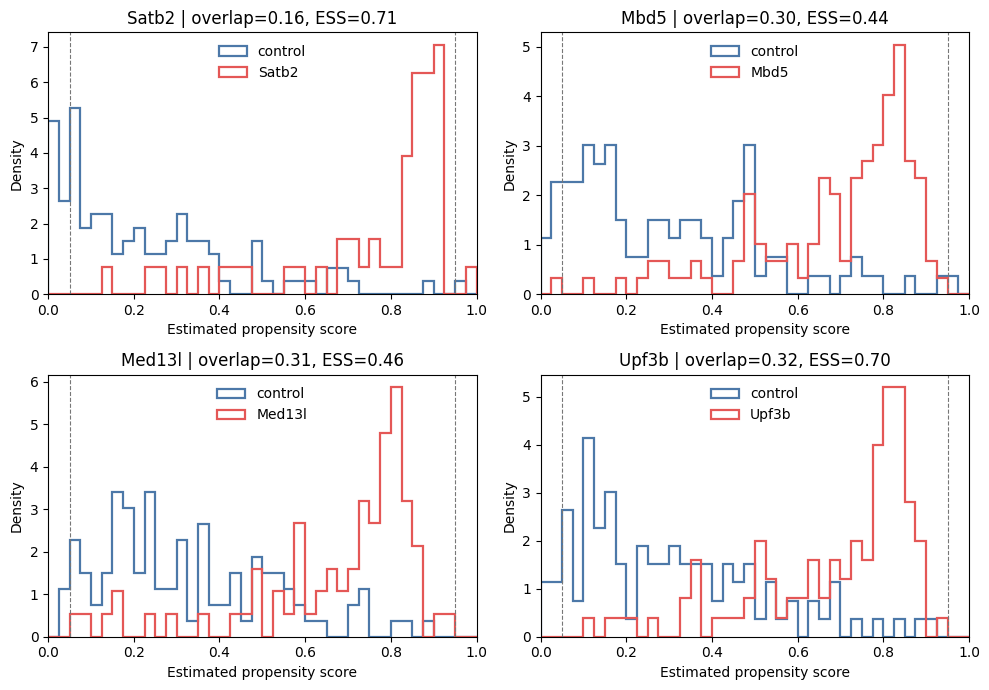

In [8]:
W_A = np.c_[X_A, U]
pi_oof = estimate_propensity_scores(
    A, W_A, K=5, class_weight='balanced', random_state=0,
)
ps_summary = summarize_propensity_scores(A, pi_oof)
display(ps_summary.sort_values('overlap_ratio').head(10))

weakest = ps_summary.nsmallest(4, 'overlap_ratio')['treatment'].tolist()
fig, axes, _ = plot_propensity_scores(A, pi_oof, treatments=weakest)
plt.show()

A large increase in Brier score from the training fit to out-of-fold prediction indicates overfitting when the same class weighting is used. Stronger regularisation (for example `C=0.1`) is helpful only when it lowers the out-of-fold Brier score; do not tune the model merely to make the histograms overlap more. Class-balanced scores are not calibrated estimates of the observed treatment prevalence, so calibration should be assessed separately with `class_weight=None`. Persistent lack of overlap under the prespecified model is a data limitation, not a tuning problem. Weight clipping or restricting to cells with scores in `[0.05, 0.95]` can be reported as sensitivity analyses, but restriction changes the target population. Do not remove an associated confounder solely to make the overlap plot look better.

In [9]:
pi_train = estimate_propensity_scores(
    A, W_A, K=1, class_weight='balanced', random_state=0,
)
ps_train = summarize_propensity_scores(A, pi_train)
pi_oof_regularized = estimate_propensity_scores(
    A, W_A, K=5, C=0.1, class_weight='balanced', random_state=0,
)
ps_regularized = summarize_propensity_scores(A, pi_oof_regularized)
overfit_check = ps_train[['treatment', 'brier_score']].rename(
    columns={'brier_score': 'brier_train_C1'}
).merge(
    ps_summary[['treatment', 'overlap_ratio', 'brier_score']].rename(
        columns={'brier_score': 'brier_oof_C1'}), on='treatment'
).merge(
    ps_regularized[['treatment', 'overlap_ratio', 'brier_score']].rename(
        columns={'overlap_ratio': 'overlap_ratio_C01', 'brier_score': 'brier_oof_C01'}),
    on='treatment',
)
display(overfit_check.sort_values('overlap_ratio').head(10))

# Reuse fitted outcome models for a propensity sensitivity analysis.
# df_oof, _ = LFC(Y, np.c_[X, U], A, W_A, offset=offsets,
#                 Y_hat=estimation['Y_hat'], pi_hat=pi_oof, usevar='pooled')

,treatment,brier_train_C1,overlap_ratio,brier_oof_C1,overlap_ratio_C01,brier_oof_C01
18,Satb2,0.075466,0.164077,0.096756,0.288198,0.146275
11,Mbd5,0.116343,0.303393,0.134982,0.452275,0.178107
12,Med13l,0.131976,0.313208,0.148720,0.448176,0.187060
27,Upf3b,0.118060,0.317547,0.135306,0.446415,0.182605
2,Asxl3,0.117547,0.319448,0.133628,0.512046,0.184543
19,Scn2a1,0.129479,0.333739,0.147952,0.502029,0.190732
20,Setd2,0.147268,0.335402,0.173702,0.514151,0.203231
17,Qrich1,0.148151,0.362440,0.169654,0.544756,0.210978
6,Ddx3x,0.146036,0.367925,0.175877,0.537736,0.206478
9,Fbxo11,0.151591,0.394612,0.168791,0.566633,0.209796


**Interpretation.** The overlap ratio is a descriptive summary, not a pass/fail threshold. Here 28 of the 29 perturbations have an out-of-fold overlap ratio above 0.25, which is compatible with useful common support for most comparisons. Satb2 is the exception: its overlap ratio is 0.164, 14.0% of scores fall outside `[0.05, 0.95]`, and its control ESS is only 39.5% of the nominal control count. Estimates for Satb2 therefore deserve more caution than those for the other perturbations.

For Satb2, one may want to try stronger propensity-model regularisation as a sensitivity analysis. In the table above, changing `C` from 1 to 0.1 raises its overlap ratio from 0.164 to 0.288, but also worsens the out-of-fold Brier score from 0.097 to 0.146. The smoother scores are therefore not automatically a better propensity model. If a scientific conclusion depends on Satb2, refit `LFC` with the same alternative `C`, compare effect estimates and discoveries, and report whether the conclusion is robust; calibrated scores (`class_weight=None`) or a restricted target population can provide additional sensitivity analyses.

### Are the latent factors associated with treatment?

For each latent factor, an omnibus one-way ANOVA tests equality across control and perturbation groups. Because large cell counts make small differences significant, treatment-explained variance (`eta2`) is reported with BH-adjusted p-values. The heatmap shows standardized differences from control for individual perturbations.

,factor,F,pvalue,eta2,padj
0,U1,0.330944,0.999727,0.003303,1.00000
1,U2,0.224609,0.999996,0.002244,1.00000
2,U3,0.192696,0.999999,0.001926,1.00000
3,U4,0.240109,0.999991,0.002399,1.00000
4,U5,0.128538,1.000000,0.001286,1.00000
5,U6,0.304299,0.999885,0.003038,1.00000
6,U7,1.471180,0.050073,0.014518,0.50073
7,U8,1.105642,0.318305,0.010950,1.00000
8,U9,1.139224,0.277604,0.011279,1.00000
9,U10,0.742114,0.838668,0.007377,1.00000


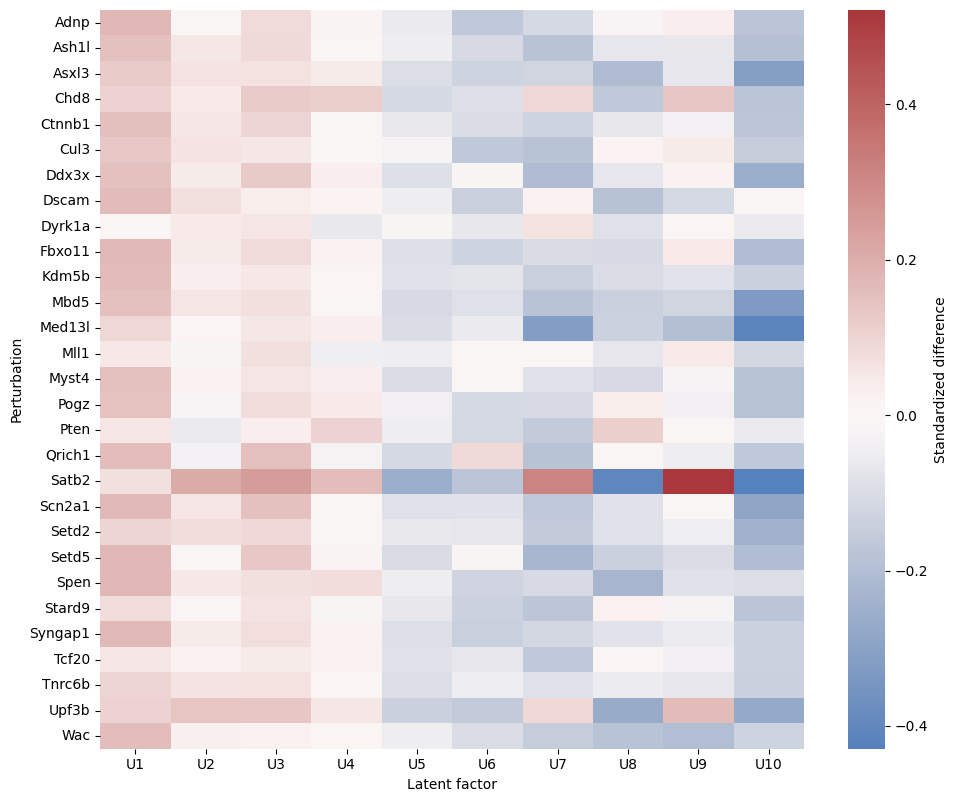

In [10]:
labels = np.full(A.shape[0], 'control', dtype=object)
for j, pert in enumerate(A.columns):
    labels[A.iloc[:, j].to_numpy() == 1] = pert
group_names = ['control', *A.columns.tolist()]

u_tests = []
for k in range(U.shape[1]):
    grouped = [U[labels == group, k] for group in group_names]
    f_stat, pvalue = stats.f_oneway(*grouped)
    grand_mean = U[:, k].mean()
    ss_between = sum(len(values) * (values.mean() - grand_mean) ** 2 for values in grouped)
    eta2 = ss_between / np.sum((U[:, k] - grand_mean) ** 2)
    u_tests.append({'factor': f'U{k + 1}', 'F': f_stat, 'pvalue': pvalue, 'eta2': eta2})
u_tests = pd.DataFrame(u_tests)
u_tests['padj'] = multipletests(u_tests['pvalue'], method='fdr_bh')[1]
display(u_tests)

ctrl = labels == 'control'
smd = pd.DataFrame(index=A.columns, columns=u_tests['factor'], dtype=float)
for pert in A.columns:
    case = labels == pert
    pooled_sd = np.sqrt((U[case].var(axis=0, ddof=1) + U[ctrl].var(axis=0, ddof=1)) / 2)
    smd.loc[pert] = (U[case].mean(axis=0) - U[ctrl].mean(axis=0)) / pooled_sd
plt.figure(figsize=(10, max(6, 0.28 * len(smd))))
sns.heatmap(smd, cmap='vlag', center=0, cbar_kws={'label': 'Standardized difference'})
plt.xlabel('Latent factor')
plt.ylabel('Perturbation')
plt.tight_layout()
plt.show()

### Treatment-specific association diagnostics and filtering

The utility functions below apply the same shared-control comparison to observed propensity covariates and latent factors. Spearman correlation captures monotone association, while the standardized mean difference gives an effect size on a familiar scale. P-values are BH-adjusted across every treatment-by-covariate pair; no automatic cutoff or drop decision is imposed.

The observed log-library-size covariate is strongly associated with several perturbations. We retain it because it represents a prespecified technical adjustment; association alone does not make an observed covariate safe to remove. Among the latent factors, Satb2--U9 has the largest standardized imbalance (Spearman $\rho \approx 0.247$, SMD $\approx 0.521$, globally adjusted $p \approx 0.023$); Satb2--U8 is also significant after global adjustment. We drop only U9 below as an explicitly exploratory one-factor sensitivity analysis. Omitting a genuine confounder does not repair a positivity violation.

,treatment,covariate,covariate_type,n_control,n_treated,spearman_rho,pvalue,padj,standardized_mean_difference,constant
217,Satb2,log_library_size,observed,106,51,-0.620601,4.352985e-18,1.388602e-15,-1.670432,False
133,Mbd5,log_library_size,observed,106,119,-0.525168,2.377952e-17,3.792833e-15,-1.196548,False
25,Asxl3,log_library_size,observed,106,130,-0.501171,2.061826e-16,2.192409e-14,-1.147867,False
325,Upf3b,log_library_size,observed,106,100,-0.524464,5.917208e-16,4.718973e-14,-1.193805,False
229,Scn2a1,log_library_size,observed,106,93,-0.479169,8.091610e-13,5.162447e-11,-1.070860,False
145,Med13l,log_library_size,observed,106,75,-0.491124,2.226940e-12,1.183990e-10,-1.072918,False
241,Setd2,log_library_size,observed,106,76,-0.450423,1.771080e-10,8.071064e-09,-0.971646,False
253,Setd5,log_library_size,observed,106,71,-0.438344,1.046791e-09,3.710293e-08,-0.952658,False
13,Ash1l,log_library_size,observed,106,122,-0.390531,1.003845e-09,3.710293e-08,-0.806900,False
109,Fbxo11,log_library_size,observed,106,111,-0.394344,1.730357e-09,5.519838e-08,-0.844210,False


,treatment,covariate,covariate_type,n_control,n_treated,spearman_rho,pvalue,padj,standardized_mean_difference,constant
226,Satb2,U9,latent,106,51,0.247280,0.001795,0.022898,0.520999,False
227,Satb2,U10,latent,106,51,-0.190262,0.016997,0.154919,-0.429236,False
155,Med13l,U10,latent,106,75,-0.205422,0.005534,0.060877,-0.411375,False
225,Satb2,U8,latent,106,51,-0.242478,0.002215,0.027178,-0.406490,False
143,Mbd5,U10,latent,106,119,-0.175056,0.008499,0.087460,-0.328204,False
152,Med13l,U7,latent,106,75,-0.101960,0.172006,0.883705,-0.319727,False
35,Asxl3,U10,latent,106,130,-0.160805,0.013386,0.125593,-0.314906,False
224,Satb2,U7,latent,106,51,0.206467,0.009477,0.094470,0.313717,False
239,Scn2a1,U10,latent,106,93,-0.148151,0.036771,0.308679,-0.284932,False
335,Upf3b,U10,latent,106,100,-0.163987,0.018508,0.163999,-0.272426,False


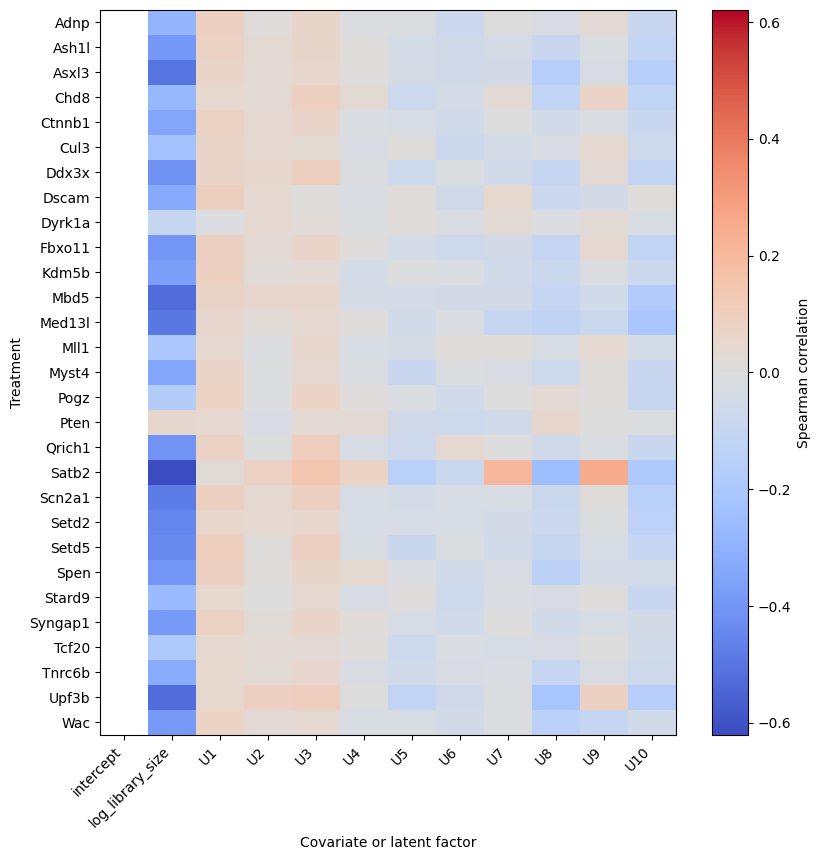

In [11]:
factor_names = [f'U{k + 1}' for k in range(U.shape[1])]
propensity_names = ['intercept', 'log_library_size', *factor_names]
propensity_types = ['observed', 'observed', *(['latent'] * U.shape[1])]
association_summary = summarize_treatment_associations(
    A, W_A, covariate_names=propensity_names,
    covariate_types=propensity_types,
)
observed_associations = association_summary.query("covariate_type == 'observed' and not constant")
latent_associations = association_summary.query("covariate_type == 'latent'").copy()
display(observed_associations.sort_values('padj').head(10))
display(
    latent_associations.assign(abs_smd=lambda frame: frame['standardized_mean_difference'].abs())
    .sort_values('abs_smd', ascending=False).drop(columns='abs_smd').head(10)
)
fig, ax = plot_treatment_associations(association_summary)
plt.show()

#### Exploratory Satb2 propensity sensitivity

Filtering and feature-specific regularization are treatment-specific: changing the Satb2 design leaves every other perturbation's propensity model unchanged. We compare dropping `U9` with retaining every covariate while applying ten times the ordinary L2 penalty to standardized log-library size only. A penalty factor of 10 is implemented by dividing that column by $\sqrt{10}$ during logistic fitting and prediction; all other coefficients retain the usual penalty. We first update Satb2's out-of-fold scores for overlap diagnostics, then update its analysis scores and reuse `estimation['Y_hat']`, so no outcome model is refitted. Both alternatives are exploratory sensitivity analyses, and their out-of-fold Brier scores should be considered alongside apparent improvements in overlap.

,treatment,dropped_covariates,retained_covariates,penalty_factors,n_retained,model
0,Satb2,[U9],"[intercept, log_library_size, U1, U2, U3, U4, ...",{},11,drop U9
0,Satb2,[],"[intercept, log_library_size, U1, U2, U3, U4, ...",{'log_library_size': 10.0},12,10x library-size penalty


,model,overlap_ratio,outside_overlap_fraction,ess_control_fraction,ess_treated_fraction,brier_score
18,all factors,0.164077,0.140127,0.394608,0.713920,0.096756
18,drop U9,0.182945,0.133758,0.402532,0.711836,0.096350
18,10x library-size penalty,0.267851,0.019108,0.723197,0.792131,0.137351


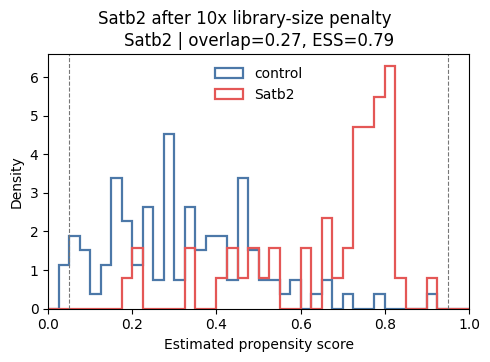

  0%|          | 0/29 [00:00<?, ?it/s]

 21%|██        | 6/29 [00:00<00:00, 51.34it/s]

 45%|████▍     | 13/29 [00:00<00:00, 59.85it/s]

 69%|██████▉   | 20/29 [00:00<00:00, 61.53it/s]

 93%|█████████▎| 27/29 [00:00<00:00, 60.07it/s]

...

 45%|████▍     | 13/29 [00:00<00:00, 60.12it/s]

 69%|██████▉   | 20/29 [00:00<00:00, 62.98it/s]

 93%|█████████▎| 27/29 [00:00<00:00, 62.36it/s]

100%|██████████| 29/29 [00:00<00:00, 61.36it/s]

,model,effect_correlation,median_absolute_change,discoveries,discoveries_all
0,drop U9,0.999765,0.004004,1852,1858
1,10x library-size penalty,0.996600,0.011748,1775,1858


In [12]:
drop_by_treatment = {'Satb2': ['U9']}

pi_oof_filtered, oof_filter_audit = refit_propensity_scores(
    A, W_A, drop_by_treatment, pi_hat=pi_oof,
    covariate_names=propensity_names, K=5,
    class_weight='balanced', random_state=0,
)
library_penalty_factor = 10
pi_oof_library_regularized, library_regularization_audit = refit_propensity_scores(
    A, W_A, pi_hat=pi_oof, covariate_names=propensity_names, K=5,
    penalty_factors_by_treatment={
        'Satb2': {'log_library_size': library_penalty_factor},
    },
    class_weight='balanced', random_state=0,
)
display(pd.concat([oof_filter_audit.assign(model='drop U9'),
                   library_regularization_audit.assign(model='10x library-size penalty')]))
satb2_overlap = pd.concat([
    summarize_propensity_scores(A, pi_oof).query("treatment == 'Satb2'").assign(model='all factors'),
    summarize_propensity_scores(A, pi_oof_filtered).query("treatment == 'Satb2'").assign(model='drop U9'),
    summarize_propensity_scores(A, pi_oof_library_regularized).query("treatment == 'Satb2'").assign(model='10x library-size penalty'),
]).loc[:, ['model', 'overlap_ratio', 'outside_overlap_fraction',
           'ess_control_fraction', 'ess_treated_fraction', 'brier_score']]
display(satb2_overlap)
fig, axes, _ = plot_propensity_scores(
    A, pi_oof_library_regularized, treatments=['Satb2'],
)
fig.suptitle('Satb2 after 10x library-size penalty', y=1.02)
plt.show()

pi_analysis_filtered, analysis_filter_audit = refit_propensity_scores(
    A, W_A, drop_by_treatment, pi_hat=estimation['pi_hat_raw'],
    covariate_names=propensity_names, K=1,
    class_weight='balanced', random_state=0,
)
pi_analysis_library_regularized, _ = refit_propensity_scores(
    A, W_A, pi_hat=estimation['pi_hat_raw'],
    covariate_names=propensity_names, K=1,
    penalty_factors_by_treatment={
        'Satb2': {'log_library_size': library_penalty_factor},
    },
    class_weight='balanced', random_state=0,
)
df_filtered, estimation_filtered = LFC(
    Y, np.c_[X, U], A, W_A, offset=offsets, usevar='pooled',
    Y_hat=estimation['Y_hat'], pi_hat=pi_analysis_filtered,
)
df_library_regularized, _ = LFC(
    Y, np.c_[X, U], A, W_A, offset=offsets, usevar='pooled',
    Y_hat=estimation['Y_hat'], pi_hat=pi_analysis_library_regularized,
)
satb2_effects = (
    df_res.query("trt == 'Satb2'")
    [['gene_names', 'tau', 'padj']].rename(columns={'tau': 'tau_all', 'padj': 'padj_all'})
    .merge(
        df_filtered.query("trt == 'Satb2'")
        [['gene_names', 'tau', 'padj']].rename(columns={'tau': 'tau_drop_u9', 'padj': 'padj_drop_u9'}),
        on='gene_names',
    )
    .merge(
        df_library_regularized.query("trt == 'Satb2'")
        [['gene_names', 'tau', 'padj']].rename(columns={'tau': 'tau_library_penalty', 'padj': 'padj_library_penalty'}),
        on='gene_names',
    )
)
display(pd.DataFrame({
    'model': ['drop U9', '10x library-size penalty'],
    'effect_correlation': [
        satb2_effects[['tau_all', 'tau_drop_u9']].corr().iloc[0, 1],
        satb2_effects[['tau_all', 'tau_library_penalty']].corr().iloc[0, 1],
    ],
    'median_absolute_change': [
        (satb2_effects['tau_all'] - satb2_effects['tau_drop_u9']).abs().median(),
        (satb2_effects['tau_all'] - satb2_effects['tau_library_penalty']).abs().median(),
    ],
    'discoveries': [
        (satb2_effects['padj_drop_u9'] < 0.1).sum(),
        (satb2_effects['padj_library_penalty'] < 0.1).sum(),
    ],
    'discoveries_all': (satb2_effects['padj_all'] < 0.1).sum(),
}))

**Sensitivity interpretation.** Applying a 10-fold L2 penalty to library size alone raises Satb2's overlap ratio from 0.164 to 0.268, reduces the fraction outside `[0.05, 0.95]` from 14.0% to 1.9%, and raises the control ESS fraction from 39.5% to 72.3%. Its out-of-fold Brier score worsens from 0.097 to 0.137, indicating that the overlap gain reflects stronger smoothing rather than better out-of-fold propensity prediction. The corresponding effects remain highly similar overall (correlation 0.997), and the modest decrease in discoveries from 1,858 to 1,775 is acceptable for this regularized sensitivity analysis rather than evidence of substantive instability. We retain the original propensity specification as the primary analysis and report both filtered specifications as sensitivities; neither establishes positivity that is absent in the data.